# Reproducing `fire_los_recovery` — 1. Truth construction

**Goal.** Re-derive, stage by stage, the FIRE m12i truth tables that
`experiments/fire_los_recovery/fire_truth.py build` produced on 2026-07-29 —
and validate every stage against the frozen originals in
`experiments/fire_los_recovery/cache/`. Companion reading:
`GUIDE_0_fire_truth.md` (physics decisions) and the experiment `README.md`.

**Validation strategy.** The July 29 run left `truth_old1gyr.npz` on disk.
Same inputs + same seeds + same library versions ⇒ the reproduction should be
**bit-exact**, and each section below asserts that. Anything not exact is a
red flag to chase, not to shrug off.

**Dependency pin (important).** The truth was built with `pytreegrav 1.1.4`.
Versions 1.2.0–1.4.0 (released 2026-08-02 → 08-04, days after the original
run!) change the tree summation at the ~1.3×10⁻³ relative level — the same
order as the tree's approximation error, so not *wrong*, but not *our frozen
truth* either. Install the pinned deps into the project env once:

```bash
uv add "pytreegrav==1.1.4" numba
```

**Caching.** The two full-stack summations (~2 min each) write to
`cache/rebuild_true.npz` / `cache/rebuild_smooth.npz` next to this notebook;
re-runs skip straight to the comparisons. Delete `cache/` to force a full
recompute.

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

HERE = Path.cwd()                       # clean_experiments/fire_sims
REPO = HERE.parents[1]
EXP = REPO / 'experiments' / 'fire_los_recovery'
CACHE = HERE / 'cache'
CACHE.mkdir(exist_ok=True)

import importlib.metadata as _md
_ptg_version = _md.version('pytreegrav')
assert _ptg_version == '1.1.4', (
    f'pytreegrav {_ptg_version} != 1.1.4 — the frozen truth was built with '
    f'1.1.4 and newer versions drift at the ~1e-3 level. '
    f'Run: uv add "pytreegrav==1.1.4" numba')

# frozen originals (the ground truth for this reproduction)
tab = np.load(EXP / 'cache' / 'particles.npz')
frozen = np.load(EXP / 'cache' / 'truth_old1gyr.npz', allow_pickle=True)
meta = json.loads(str(frozen['meta']))

# constants, taken from the frozen metadata so we can't fat-finger them
OBSERVER = np.asarray(meta['observer_kpc'])      # (-8.1, 0, 0) kpc
GC = np.asarray(meta['gc_kpc'])                  # (0, 0, 0)
G = meta['G_kpc3_msun_myr2']                     # ~4.4985e-12
SPLINE_PER_PLUMMER = meta['spline_per_plummer']  # h = 2.8 eps
THETA = meta['theta']                            # 0.5
SMOOTH_EPS = meta['smooth_eps_plummer_kpc']      # 0.5 kpc
KPCMYR2_TO_MMSYR = 977.79222

pos, mass, eps = tab['pos'], tab['mass'], tab['eps']
star_lo, star_hi = tab['star_offset']
star_pos = pos[star_lo:star_hi]
star_age = tab['star_age']
star_pot_stored = tab['star_pot_stored']
print(f'particle table: {pos.shape[0]:,} particles '
      f'({star_hi - star_lo:,} stars), pytreegrav {_ptg_version}')
print(f'G = {G:.6e} kpc^3/(Msun Myr^2), theta = {THETA}, '
      f'h/eps = {SPLINE_PER_PLUMMER}')

particle table: 147,064,162 particles (13,976,485 stars), pytreegrav 1.1.4
G = 4.498502e-12 kpc^3/(Msun Myr^2), theta = 0.5, h/eps = 2.8


## Stage 1 — tracers and query sets

Physics choices (GUIDE_0 §4):

- **Tracers = star particles with age > 1 Gyr** — the old population
  millisecond pulsars belong to. No density function, no KDE, no rejection
  sampling: FIRE star particles are near-equal-mass, so drawing particles
  uniformly *is* drawing positions from the stellar mass density.
- **Training pool**: 30,000 tracers in the 4 kpc ball around the Sun,
  `default_rng(0)`, without replacement.
- **Validation regions** (`sun4`, `sun15`, `gc15`): 4096 each, seeds
  `100+i` in region order, **excluding pool particles** — with a finite
  particle set, sun4/sun15 val would otherwise literally contain training
  points.
- The query stack also carries three special points: the Sun (`obs`), the
  Galactic center (`gc`, for the frame correction) and a 300 kpc reference
  (`ref`, for the potential gauge).

In [2]:
is_tracer = star_age > 1.0
d_sun = np.linalg.norm(star_pos - OBSERVER, axis=1)

regions = {'sun4': (OBSERVER, 4.0), 'sun15': (OBSERVER, 15.0),
           'gc15': (GC, 15.0)}

cand = np.where(is_tracer & (d_sun < 4.0))[0]
pool_idx = np.random.default_rng(0).choice(cand, size=30000, replace=False)
print(f'training pool: 30,000 of {cand.size:,} in-ball tracers')

pool_mask = np.zeros(star_pos.shape[0], dtype=bool)
pool_mask[pool_idx] = True
val_idx = {}
for i, (name, (center, radius)) in enumerate(regions.items()):
    dc = np.linalg.norm(star_pos - center[None, :], axis=1)
    c = np.where(is_tracer & ~pool_mask & (dc < radius))[0]
    val_idx[name] = np.random.default_rng(100 + i).choice(
        c, size=min(4096, c.size), replace=False)
    print(f'val {name:5s}: {val_idx[name].size:,} of {c.size:,} candidates')

# assemble the query stack exactly like fire_truth.py build
blocks = {'pool': star_pos[pool_idx].astype(np.float64)}
for name in regions:
    blocks[name] = star_pos[val_idx[name]].astype(np.float64)
blocks['obs'] = OBSERVER[None, :].astype(np.float64)
blocks['gc'] = GC[None, :].astype(np.float64)
blocks['ref'] = np.array([[0.0, 0.0, 300.0]])
x_q = np.vstack(list(blocks.values()))
slices, j0 = {}, 0
for k, v in blocks.items():
    slices[k] = slice(j0, j0 + v.shape[0]); j0 += v.shape[0]
print(f'total query points: {x_q.shape[0]:,}')

# ---- VALIDATE vs frozen: positions must match EXACTLY ----
assert np.array_equal(blocks['pool'], frozen['x_pool'])
for name in regions:
    assert np.array_equal(blocks[name], frozen[f'x_val|{name}'])
assert np.array_equal(blocks['obs'], frozen['x_obs'])
print('query sets: EXACT match to the frozen truth cache ✓')

training pool: 30,000 of 304,214 in-ball tracers
val sun4 : 4,096 of 274,214 candidates
val sun15: 4,096 of 10,186,773 candidates
val gc15 : 4,096 of 10,691,905 candidates
total query points: 42,291
query sets: EXACT match to the frozen truth cache ✓


## Stage 1b — ages in the bubble: does the age cut change the sampling?

Two different things could matter about sampling: **where mass is**
(tracer density — handled by drawing particles) and **which stars count as
tracers** (the age > 1 Gyr cut). Here we look at the bubble's age
distribution and ask how much the cut changes the sampled *geometry* —
i.e. would an all-stars ablation (`fire_truth.py build --age-min 0`) sample
noticeably different positions?

bubble stars: 351,321  |  old (>1 Gyr): 304,214 (86.6%)  young: 47,107 (13.4%)
  all   : median |z| = 0.598 kpc, median R_gc = 6.73 kpc
  old   : median |z| = 0.660 kpc, median R_gc = 6.63 kpc
  young : median |z| = 0.316 kpc, median R_gc = 7.35 kpc


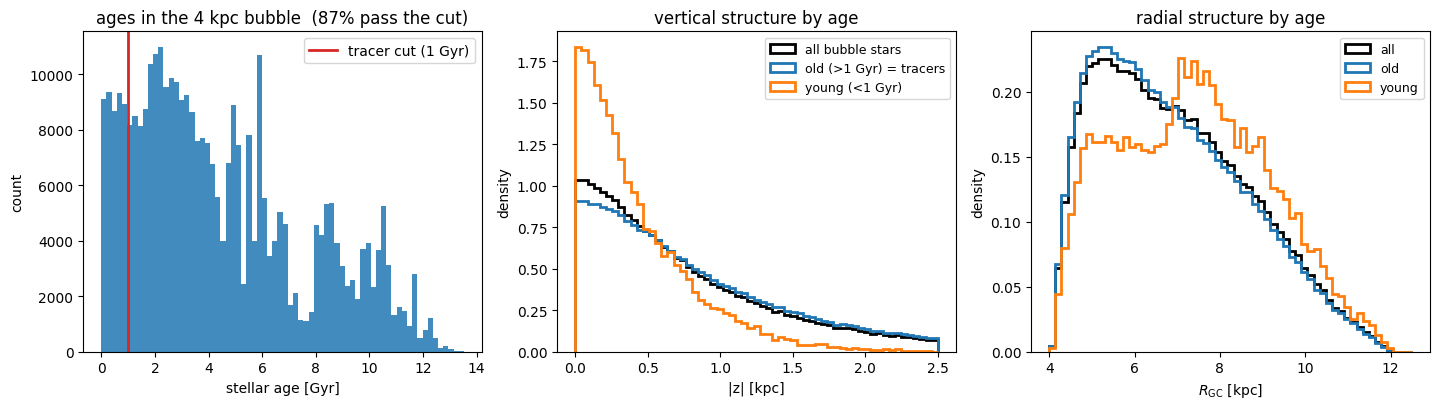

In [3]:
in_bubble = d_sun < 4.0
age_b = star_age[in_bubble]
xyz_b = star_pos[in_bubble]
old = age_b > 1.0
R_gc = np.hypot(xyz_b[:, 0], xyz_b[:, 1])
absz = np.abs(xyz_b[:, 2])

print(f'bubble stars: {in_bubble.sum():,}  |  old (>1 Gyr): {old.sum():,} '
      f'({100*old.mean():.1f}%)  young: {(~old).sum():,} '
      f'({100*(~old).mean():.1f}%)')
for label, m in [('all   ', np.ones_like(old)), ('old   ', old),
                 ('young ', ~old)]:
    m = m.astype(bool)
    print(f'  {label}: median |z| = {np.median(absz[m]):.3f} kpc, '
          f'median R_gc = {np.median(R_gc[m]):.2f} kpc')

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.2))

ax = axes[0]
ax.hist(age_b, bins=70, color='C0', alpha=0.85)
ax.axvline(1.0, color='C3', lw=2, label='tracer cut (1 Gyr)')
ax.set_xlabel('stellar age [Gyr]')
ax.set_ylabel('count')
ax.set_title(f'ages in the 4 kpc bubble  ({100*old.mean():.0f}% pass the cut)')
ax.legend()

ax = axes[1]
bins = np.linspace(0, 2.5, 60)
ax.hist(absz, bins=bins, density=True, histtype='step', lw=2,
        color='k', label='all bubble stars')
ax.hist(absz[old], bins=bins, density=True, histtype='step', lw=2,
        color='C0', label='old (>1 Gyr) = tracers')
ax.hist(absz[~old], bins=bins, density=True, histtype='step', lw=2,
        color='C1', label='young (<1 Gyr)')
ax.set_xlabel('|z| [kpc]')
ax.set_ylabel('density')
ax.set_title('vertical structure by age')
ax.legend(fontsize=9)

ax = axes[2]
bins = np.linspace(4, 12.5, 60)
ax.hist(R_gc, bins=bins, density=True, histtype='step', lw=2,
        color='k', label='all')
ax.hist(R_gc[old], bins=bins, density=True, histtype='step', lw=2,
        color='C0', label='old')
ax.hist(R_gc[~old], bins=bins, density=True, histtype='step', lw=2,
        color='C1', label='young')
ax.set_xlabel(r'$R_{\rm GC}$ [kpc]')
ax.set_ylabel('density')
ax.set_title('radial structure by age')
ax.legend(fontsize=9)
fig.tight_layout()

**Reading the panels.** The young (<1 Gyr) population is a thin,
clumpy midplane/arm population; the old tracers are vertically puffier and
radially smoother. But because the young stars are only a small fraction of
the bubble, the **all-stars sampling geometry is close to the old-only
one** — the age cut is more about *physical fidelity* (MSPs are old, and
young stars cluster in exactly the GMC complexes whose graininess we can't
model) than about moving the sampled positions wholesale. The quantitative
ablation (`--age-min 0`) is still an open experiment TODO in the README.

## Stage 1c — the same radial structure, whole galaxy vs bubble

The panels above were **bubble-only** (`d_sun < 4` is applied before anything
is histogrammed). Here we drop that cut and look at every star particle in
the table. Two caveats for reading it:

- The table holds the **entire high-res zoom region**, not just the host
  disk — satellites and the stellar halo are in here too (~16% of stars sit
  beyond 25 kpc, where the left panel is truncated).
- As above, these are histograms of star counts per kpc in $R$, i.e.
  $\propto 2\pi R\,\Sigma(R)$ azimuth- and $z$-integrated — the *sampling
  distribution* of tracer positions, not the surface-density profile
  $\Sigma(R)$ itself (divide by $2\pi R$ for that).

The right panel restricts both populations to the bubble's radial annulus
(density re-normalized in the window) so the shapes are directly comparable:
what the bubble samples in $R$ vs what the galaxy actually does there.

In [ ]:
R_SUN = np.linalg.norm(OBSERVER[:2])          # 8.1 kpc
old_all = star_age > 1.0                      # same cut as is_tracer
R_all = np.hypot(star_pos[:, 0], star_pos[:, 1])
absz_all = np.abs(star_pos[:, 2])

print(f'whole population: {star_pos.shape[0]:,} stars  |  '
      f'old (>1 Gyr): {old_all.sum():,} ({100*old_all.mean():.1f}%)  '
      f'young: {(~old_all).sum():,} ({100*(~old_all).mean():.1f}%)')
for label, m in [('all   ', np.ones_like(old_all)), ('old   ', old_all),
                 ('young ', ~old_all)]:
    m = m.astype(bool)
    print(f'  {label}: median |z| = {np.median(absz_all[m]):.3f} kpc, '
          f'median R_gc = {np.median(R_all[m]):.2f} kpc, '
          f'{100*np.mean(R_all[m] > 25):.1f}% beyond 25 kpc')
print(f'  bubble contains {100*in_bubble.mean():.1f}% of all stars '
      f'({100*(in_bubble & old_all).sum()/old_all.sum():.1f}% of old)')

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))

ax = axes[0]
bins = np.linspace(0, 25, 100)
ax.hist(R_all, bins=bins, density=True, histtype='step', lw=2,
        color='k', label='all stars')
ax.hist(R_all[old_all], bins=bins, density=True, histtype='step', lw=2,
        color='C0', label='old (>1 Gyr)')
ax.hist(R_all[~old_all], bins=bins, density=True, histtype='step', lw=2,
        color='C1', label='young (<1 Gyr)')
ax.axvspan(R_SUN - 4.0, R_SUN + 4.0, color='C3', alpha=0.08,
           label='bubble radial range')
ax.set_xlabel(r'$R_{\rm GC}$ [kpc]')
ax.set_ylabel('density')
ax.set_title('radial structure by age — whole galaxy')
ax.legend(fontsize=9)

ax = axes[1]
bins = np.linspace(4, 12.5, 60)
for m_pop, color, name in [(old_all, 'C0', 'old'),
                           (~old_all, 'C1', 'young')]:
    ax.hist(R_all[m_pop], bins=bins, density=True, histtype='step', lw=2,
            color=color, label=f'{name}, whole galaxy')
    ax.hist(R_all[m_pop & in_bubble], bins=bins, density=True,
            histtype='step', lw=2, ls='--', color=color,
            label=f'{name}, bubble only')
ax.axvline(R_SUN, color='C3', lw=1, alpha=0.6)
ax.set_xlabel(r'$R_{\rm GC}$ [kpc]')
ax.set_ylabel('density (normalized in window)')
ax.set_title('same radial window: galaxy vs 4 kpc bubble')
ax.legend(fontsize=9)
fig.tight_layout()

## Stage 2 — the truth engine: softened summation over all particles

Two fields, same 42,291-point query stack (GUIDE_0 §2):

- **TRUE field** — pytreegrav octree over all ~147M particles, opening
  angle θ = 0.5, quadrupole moments, per-type GIZMO softenings passed as the
  M4 spline support radius h = 2.8 ε_Plummer (star/gas 4 pc, DM 40 pc).
  This *is* the field the snapshot defines — deliberately NOT the fitted
  BFE/EXP coefficient files.
- **SMOOTHED reference** — identical sweep with one uniform 0.5 kpc
  Plummer-equivalent softening. Every downstream error metric is computed
  against both; the gap is the irreducible "graininess floor".

Each sweep is ~2 min on this machine and is cached to `cache/` after the
first run.

In [4]:
from pytreegrav import AccelTarget, PotentialTarget

def tree_fields(x_query, soft_spline):
    """(a, phi) in kpc/Myr^2, kpc^2/Myr^2 — mirrors fire_truth.tree_fields."""
    pos64 = pos.astype(np.float64)
    m64 = mass.astype(np.float64)
    a, tree = AccelTarget(x_query, pos64, m64, softening_source=soft_spline,
                          G=G, theta=THETA, parallel=True, quadrupole=True,
                          return_tree=True)
    phi = PotentialTarget(x_query, pos64, m64, softening_source=soft_spline,
                          G=G, theta=THETA, parallel=True, quadrupole=True,
                          tree=tree)
    del tree, pos64, m64
    return np.asarray(a, np.float64), np.asarray(phi, np.float64)

def cached_sweep(name, soft):
    f = CACHE / f'rebuild_{name}.npz'
    if f.exists():
        z = np.load(f)
        print(f'{name}: loaded from cache ({f.name})')
        return z['a'], z['phi']
    t0 = time.time()
    a, phi = tree_fields(x_q, soft)
    np.savez(f, a=a, phi=phi)
    print(f'{name}: computed in {time.time()-t0:.0f} s -> {f.name}')
    return a, phi

soft_true = (eps * SPLINE_PER_PLUMMER).astype(np.float64)
soft_smooth = np.full(pos.shape[0], SMOOTH_EPS * SPLINE_PER_PLUMMER)

a_raw, phi_raw = cached_sweep('true', soft_true)
a_sm_raw, phi_sm_raw = cached_sweep('smooth', soft_smooth)

true: loaded from cache (rebuild_true.npz)
smooth: loaded from cache (rebuild_smooth.npz)


## Stage 3 — frame and gauge corrections

Two things an analytic-potential experiment never needed (GUIDE_0 §3):

1. **Host-frame acceleration.** The isolated sum feels the rest of the
   cosmological box (~2.3×10¹⁶ M☉ of low-res mass) as a quasi-uniform pull —
   ~4.6% of the Sun's acceleration — which the real simulation largely
   cancels via periodic (Ewald) gravity. All labels become
   `a(x) − a_frame` with `a_frame ≡ a_smooth(GC)` (the *smoothed* field at
   the host center, stable against central graininess).
2. **Potential gauge + tilt.** (a) Subtracting a constant vector from `a`
   is a *linear* change to the potential, so `phi` gets the matching tilt
   `+ a_frame · x` — keeping `−∇u = a` exact. (b) The isolated-sum potential
   carries a ~−2.7 kpc²/Myr² constant from distant mass; re-zero at the
   (0, 0, 300) kpc reference so the `u* = max|u_train|` scaling isn't
   corrupted ~15×.

We derive `a_frame` and `u0` from **our own rebuilt fields** and compare
them — and every corrected label — against the frozen cache.

In [5]:
a_frame = a_sm_raw[slices['gc']][0].copy()
a_true = a_raw - a_frame[None, :]
a_sm = a_sm_raw - a_frame[None, :]
tilt = x_q @ a_frame
phi_true = phi_raw + tilt
phi_sm = phi_sm_raw + tilt
u0 = float(phi_true[slices['ref']][0])
phi_true = phi_true - u0
phi_sm = phi_sm - u0

# compare the corrections themselves to the recorded ones
fr = meta['checks']['frame']
print(f"a_frame: {np.linalg.norm(a_frame)*KPCMYR2_TO_MMSYR:.4f} mm/s/yr "
      f"(frozen {fr['a_frame_mag_mmsyr']:.4f}), "
      f"max |delta| = {np.abs(a_frame - np.array(fr['a_frame_kpcmyr2'])).max():.3e}")
print(f"u0: {u0:.6f} kpc^2/Myr^2 (frozen {fr['u0_kpc2myr2']:.6f})")

# ---- VALIDATE every stored label against the frozen truth cache ----
def maxrel(mine, ref):
    ref = np.asarray(ref)
    denom = np.linalg.norm(ref, axis=-1) if ref.ndim > 1 else np.abs(ref)
    diff = (np.linalg.norm(mine - ref, axis=-1) if ref.ndim > 1
            else np.abs(mine - ref))
    return float((diff / np.maximum(denom, 1e-300)).max())

pairs = [('a_pool', a_true[slices['pool']], frozen['a_pool']),
         ('u_pool', phi_true[slices['pool']], frozen['u_pool']),
         ('a_pool_smooth', a_sm[slices['pool']], frozen['a_pool_smooth']),
         ('a_obs', a_true[slices['obs']], frozen['a_obs'])]
for name in regions:
    pairs += [(f'a_val|{name}', a_true[slices[name]], frozen[f'a_val|{name}']),
              (f'u_val|{name}', phi_true[slices[name]], frozen[f'u_val|{name}']),
              (f'a_val_smooth|{name}', a_sm[slices[name]],
               frozen[f'a_val_smooth|{name}'])]
worst = 0.0
for label, mine, ref in pairs:
    r = maxrel(mine, ref)
    worst = max(worst, r)
    print(f'  {label:18s} max rel diff = {r:.2e}')
assert worst < 1e-12, 'reproduction is NOT bit-exact — investigate!'
print('truth labels: bit-exact reproduction of the frozen cache ✓')

a_frame: 0.3369 mm/s/yr (frozen 0.3369), max |delta| = 0.000e+00
u0: -2.709260 kpc^2/Myr^2 (frozen -2.709260)
  a_pool             max rel diff = 0.00e+00
  u_pool             max rel diff = 0.00e+00
  a_pool_smooth      max rel diff = 0.00e+00
  a_obs              max rel diff = 0.00e+00
  a_val|sun4         max rel diff = 0.00e+00
  u_val|sun4         max rel diff = 0.00e+00
  a_val_smooth|sun4  max rel diff = 0.00e+00
  a_val|sun15        max rel diff = 0.00e+00
  u_val|sun15        max rel diff = 0.00e+00
  a_val_smooth|sun15 max rel diff = 0.00e+00
  a_val|gc15         max rel diff = 0.00e+00
  u_val|gc15         max rel diff = 0.00e+00
  a_val_smooth|gc15  max rel diff = 0.00e+00
truth labels: bit-exact reproduction of the frozen cache ✓


## Stage 4 — physics validation gates

The build hard-fails on these (a sign/unit/G bug shows up as O(1) here):

1. **Summed Φ vs GIZMO's stored per-particle potential** on the pool block
   (slope must be ~1; the offset is arbitrary — stored Φ has its own zero).
2. **Circular-velocity profile** from the field at the gc15 points
   (v_c(R☉) must land in (150, 350) km/s; compare with stellar v_φ ≈ 206 —
   the ~30 km/s gap is asymmetric drift, as it should be).
3. **The Sun anchor** in intuition units (mm/s/yr).
4. **Graininess**: |a_true − a_smooth| / |a_true| per region — the floor a
   smooth model cannot beat when evaluated against the clumpy truth.

potential regression: slope 0.9683 (gate: 0.8-1.2), corr 0.999948
Sun anchor |a| = 7.255 mm/s/yr (frozen 7.255; analytic MW ~6.6)


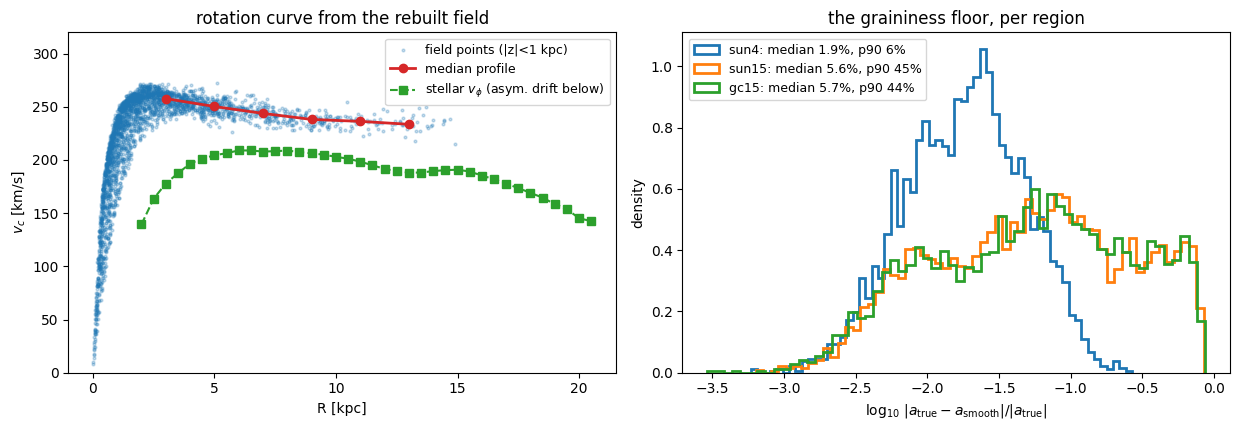

In [6]:
KMS2_TO_KPC2MYR2 = (1.0 / 977.79222) ** 2  # (km/s)^2 -> kpc^2/Myr^2

# (1) potential regression
p_stored = star_pot_stored[pool_idx].astype(np.float64) * KMS2_TO_KPC2MYR2
p_sum = phi_true[slices['pool']]
A = np.vstack([p_stored, np.ones_like(p_stored)]).T
coef, *_ = np.linalg.lstsq(A, p_sum, rcond=None)
corr = np.corrcoef(p_stored, p_sum)[0, 1]
print(f'potential regression: slope {coef[0]:.4f} (gate: 0.8-1.2), '
      f'corr {corr:.6f}')
assert 0.8 < coef[0] < 1.2

# (2) v_c profile from the corrected field
xg, ag = x_q[slices['gc15']], a_true[slices['gc15']]
Rg = np.hypot(xg[:, 0], xg[:, 1])
aR = -(ag[:, 0] * xg[:, 0] + ag[:, 1] * xg[:, 1]) / np.maximum(Rg, 1e-12)
vc = np.sqrt(np.maximum(Rg * aR, 0.0)) / np.sqrt(KMS2_TO_KPC2MYR2)
thin = np.abs(xg[:, 2]) < 1.0

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
ax = axes[0]
ax.scatter(Rg[thin], vc[thin], s=4, alpha=0.25, c='C0',
           label='field points (|z|<1 kpc)')
mids, meds = [], []
for lo in (2, 4, 6, 8, 10, 12):
    m = thin & (Rg >= lo) & (Rg < lo + 2)
    if m.sum() > 10:
        mids.append(lo + 1.0); meds.append(np.median(vc[m]))
ax.plot(mids, meds, 'o-', c='C3', lw=2, label='median profile')
vphi = meta['checks']['vphi_profile_from_stars']
ax.plot([e + 1 for e in vphi['r_edges_kpc'][:-1]], vphi['median_vphi_kms'],
        's--', c='C2', lw=1.5, label=r'stellar $v_\phi$ (asym. drift below)')
ax.set_xlabel('R [kpc]'); ax.set_ylabel(r'$v_c$ [km/s]')
ax.set_title('rotation curve from the rebuilt field')
ax.set_ylim(0, 320); ax.legend(fontsize=9)

# (3) anchor
a_obs_mag = np.linalg.norm(a_true[slices['obs']]) * KPCMYR2_TO_MMSYR
print(f'Sun anchor |a| = {a_obs_mag:.3f} mm/s/yr '
      f'(frozen {meta["checks"]["anchor"]["a_obs_mag_mmsyr"]:.3f}; '
      f'analytic MW ~6.6)')

# (4) graininess per region
ax = axes[1]
for name, color in [('sun4', 'C0'), ('sun15', 'C1'), ('gc15', 'C2')]:
    s = slices[name]
    d = (np.linalg.norm(a_true[s] - a_sm[s], axis=1)
         / np.linalg.norm(a_true[s], axis=1))
    ax.hist(np.log10(d), bins=60, density=True, histtype='step', lw=2,
            color=color,
            label=f'{name}: median {100*np.median(d):.1f}%, '
                  f'p90 {100*np.percentile(d, 90):.0f}%')
ax.set_xlabel(r'$\log_{10}\, |a_{\rm true}-a_{\rm smooth}|/|a_{\rm true}|$')
ax.set_ylabel('density')
ax.set_title('the graininess floor, per region')
ax.legend(fontsize=9)
fig.tight_layout()

## Stage 5 — catalog interlude: is σ(a_LOS) independent of the signal?

The noise arm (notebook 03, via `noise.py`) treats measurement noise as
**absolute**: sigmas live in physical mm/s/yr, and the `het` family
resamples the 51 real catalog σ values with replacement, *unpaired* with the
tracer's position or signal. That is only the right generative model if, in
the real catalog, σ(a_LOS) does not track the measured acceleration — if
precision were signal-dependent, the injection would be missing structure.

Check it directly on `data/pulsars/data.csv` (the Donlon table both LOS
channels come from): scatter σ(a_LOS) against |a_LOS| for the
spin-period-derivative and orbital-period-derivative channels. For
reference, `noise.py`'s 51-entry sigma list is this table's `ALOS_PB_ERR`
where the orbital channel exists (27 pulsars), else `ALOS_PS_ERR` (24), with
J0125-2327 and J1400-1431 present here but not in the Donlon+2025 51.

catalog: 53 pulsars from /Users/pablom.perez/Desktop/Linas-group/data/pulsars/data.csv
  ALOS_PS: n=41, 56% of points above 1 sigma
  ALOS_PB: n=27, 48% of points above 1 sigma
  per-pulsar best channel (n=53): Spearman rho = 0.17 (p = 0.22)


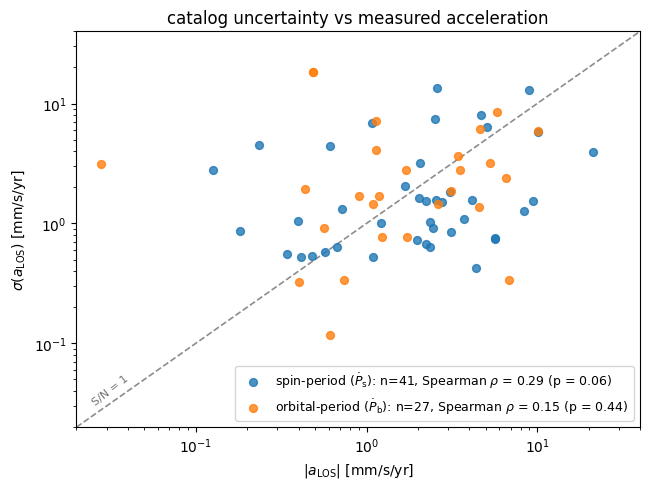

In [7]:
from scipy import stats

CAT_CSV = REPO.parent / 'data' / 'pulsars' / 'data.csv'
cat = np.genfromtxt(CAT_CSV, delimiter=',', names=True, encoding='utf-8')
cat = cat[~np.isnan(cat['GL'])]          # first data row is the units line
print(f'catalog: {cat.size} pulsars from {CAT_CSV}')

channels = {'spin-period ($\\dot P_{\\rm s}$)': ('ALOS_PS', 'C0'),
            'orbital-period ($\\dot P_{\\rm b}$)': ('ALOS_PB', 'C1')}

fig, ax = plt.subplots(figsize=(6.6, 5.0))
lims = np.array([0.02, 40.0])
ax.plot(lims, lims, ls='--', c='0.55', lw=1.2, zorder=0)
ax.annotate('S/N = 1', (0.024, 0.031), fontsize=8, color='0.45', rotation=38)
for label, (col, color) in channels.items():
    a, s = cat[col], cat[col + '_ERR']
    ok = ~np.isnan(a) & ~np.isnan(s)
    a, s = np.abs(a[ok]), s[ok]
    rho, p = stats.spearmanr(a, s)
    ax.scatter(a, s, s=32, c=color, alpha=0.8,
               label=f'{label}: n={ok.sum()}, '
                     f'Spearman $\\rho$ = {rho:.2f} (p = {p:.2f})')
    print(f'  {col:7s}: n={ok.sum():2d}, '
          f'{100*np.mean(a > s):.0f}% of points above 1 sigma')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel(r'$|a_{\rm LOS}|$ [mm/s/yr]')
ax.set_ylabel(r'$\sigma(a_{\rm LOS})$ [mm/s/yr]')
ax.set_title('catalog uncertainty vs measured acceleration')
ax.legend(fontsize=9, loc='lower right')
fig.tight_layout()

# per-pulsar view matching the noise arm's sigma list (P_b channel preferred,
# else P_s; noise.py keeps 51 of these 53)
has_pb = ~np.isnan(cat['ALOS_PB_ERR'])
a_pp = np.abs(np.where(has_pb, cat['ALOS_PB'], cat['ALOS_PS']))
s_pp = np.where(has_pb, cat['ALOS_PB_ERR'], cat['ALOS_PS_ERR'])
rho, p = stats.spearmanr(a_pp, s_pp)
print(f'  per-pulsar best channel (n={a_pp.size}): '
      f'Spearman rho = {rho:.2f} (p = {p:.2f})')

**Reading it.** No significant correlation in either channel (spin:
ρ = 0.29, p = 0.06; orbital: ρ = 0.15, p = 0.44; per-pulsar best channel:
ρ = 0.17, p = 0.22): the uncertainty is set by timing and distance precision
(σ already carries the Shklovskii-propagated distance error), not by how
large the acceleration is. Two consequences: (i) the noise arm's
independence assumption — resampling σ unpaired with the signal — is
faithful to the catalog; (ii) roughly half the catalog sits below the
S/N = 1 line (56% / 48% of points above it per channel), the "typical
pulsar ≲ 1σ" regime the whitened arms are built for. The mild positive
tendency in the spin channel is not significant at n = 41; if real, it
plausibly reflects the Shklovskii term μ²d entering both the value and its
error budget at large distance / proper motion.

## Wrap-up

Proven in this notebook, against the frozen 2026-07-29 artifacts:

- tracer selection and all seeded query sets — **exact**;
- the two full summations + frame/gauge corrections — **bit-exact** labels
  (`a_pool`, `u_pool`, all val regions, smoothed companions, Sun anchor);
- the physics gates (Φ regression, rotation curve, anchor, graininess floor)
  re-derived from the rebuilt field.

Next: `02_clean_recovery.ipynb` — the scaling contract, the five training
modes, the vmapped ensemble driver, and the recovery-vs-n results, checked
row-by-row against `results_vmap/results.csv`. Trained weights are
checkpointed so re-runs are fast.